# **Classification: Random Forest Classifier (RFC)**

## **Justification of Preprocessing Strategy**

### **Scale Invariance**
The Random Forest Classifier is an ensemble method built entirely upon Decision Trees. Because individual trees partition data based on discrete threshold rules rather than calculating geometric distances, the entire ensemble inherits this mathematical scale-invariance. Standardization or Normalization will not alter the model's splitting logic or improve predictive performance. To preserve clinical interpretability and maximize computational efficiency, we will train the model using the **Original, Unscaled Data**.

### **Architectural Knowledge Transfer (Structural Regularization)**
By default, Scikit-Learn's Random Forest allows base trees to grow unconstrained, which inevitably leads to severe memorization (Overfitting). Instead of starting blind, we will apply **Architectural Knowledge Transfer**. We extract the structural boundaries discovered in our standalone Decision Tree Classifier champion (`criterion=gini`, `max_depth=10`, `min_samples_split=10`, `min_samples_leaf=5`) and inject them as the foundational blueprint for every tree in our forest. This guarantees a mathematically safe baseline that respects our strict Train-Test generalization policy.

## **Experiment Design**

We designed a tournament of 3 optimization levels. All optimization algorithms are explicitly instructed to maximize **Recall** (to minimize false negatives in diabetes diagnosis) while we rigorously log both Train and Test metrics to enforce our generalization filter (preventing the Train/Test gap from exceeding ±0.5%).

* **Architectural Baseline**: 100 trees built using the exact structural parameters of our Decision Tree champion, establishing a robust, pre-regularized performance floor.
* **GridSearchCV**: A highly targeted 3-fold cross-validated search exploring around our champion's boundaries. We focus primarily on ensemble-specific mechanisms such as `max_features` (to decorrelate the trees) and ensemble size (`n_estimators`).
* **Optuna Optimization**: Bayesian optimization utilizing a safe trial budget to explore the continuous parameter space around our champion's depth and leaf constraints, while introducing data starvation (`max_samples`) to maximize ensemble diversity.

[I 2026-05-22 21:56:05,488] A new study created in memory with name: no-name-9b211eb8-5bb5-46c5-a53c-8087138b8968
[I 2026-05-22 21:56:09,976] Trial 0 finished with value: 0.8694734714492642 and parameters: {'n_estimators': 166, 'max_depth': 12, 'min_samples_leaf': 17, 'min_samples_split': 19, 'max_features': 'log2', 'max_samples': 0.7708465787475547}. Best is trial 0 with value: 0.8694734714492642.
[I 2026-05-22 21:56:23,460] Trial 1 finished with value: 0.8689758314740735 and parameters: {'n_estimators': 130, 'max_depth': 9, 'min_samples_leaf': 5, 'min_samples_split': 16, 'max_features': 1.0, 'max_samples': 0.7271847725847548}. Best is trial 0 with value: 0.8694734714492642.
[I 2026-05-22 21:56:42,744] Trial 2 finished with value: 0.8689758314740735 and parameters: {'n_estimators': 143, 'max_depth': 12, 'min_samples_leaf': 17, 'min_samples_split': 15, 'max_features': 1.0, 'max_samples': 0.8184521026701183}. Best is trial 0 with value: 0.8694734714492642.
[I 2026-05-22 21:56:47,094] Tr

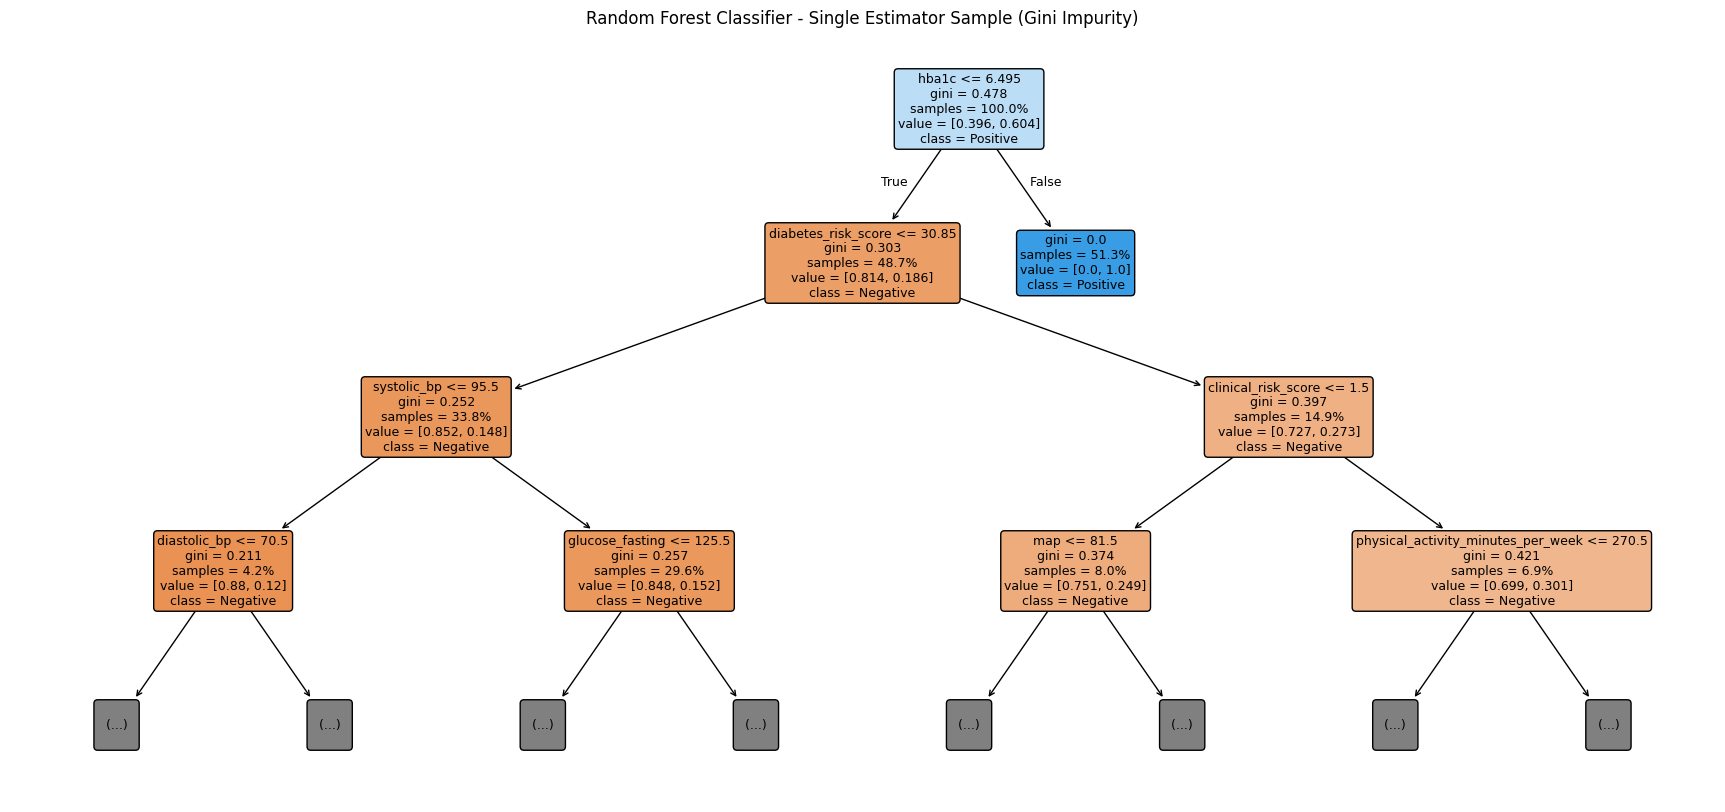

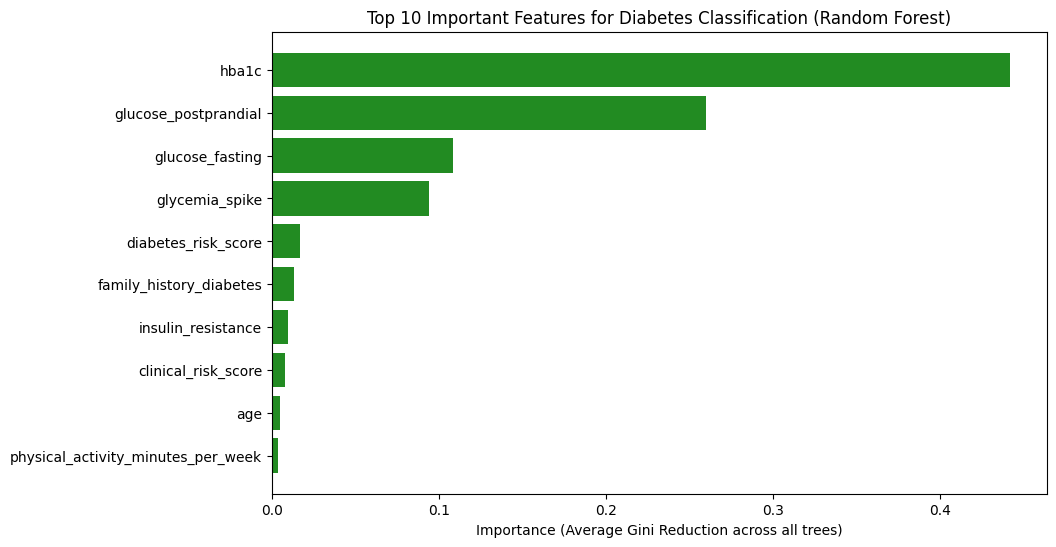

In [1]:
import pandas as pd
import numpy as np
import time
import mlflow
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import recall_score, accuracy_score, f1_score

# 1. MLflow Configuration
mlflow.set_tracking_uri("sqlite:///C:/Users/Tiago Silva/Uni/OneDrive - Universidade Portucalense/Ambiente de Trabalho/Uni/3ano2sem/LAD/Grupo5_ProjetoLAD_Parte2/TrabalhoLAD/models/mlflow.db")
mlflow.set_experiment("Classification_RandomForest")

# 2. Data Loading and Preparation
df = pd.read_csv("C:\\Users\\Tiago Silva\\Uni\\OneDrive - Universidade Portucalense\\Ambiente de Trabalho\\Uni\\3ano2sem\\LAD\\Grupo5_ProjetoLAD_Parte2\\TrabalhoLAD\\data\\diabetes_dataset_new_variables.csv")

categorical_cols = [
    'gender', 'ethnicity', 'smoking_status', 'education_level',
    'employment_status', 'age_groups', 'weight_status', 'income_level'
]

# Apply One-Hot Encoding
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features and target 
X = df_final.drop(["diagnosed_diabetes", "diabetes_stage"], axis=1)
y = df_final['diagnosed_diabetes']

# Split data (80/20) - Stratified for Classification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

SEED = 42

def log_rfc_metrics(model, X_tr, y_tr, X_te, y_te, duration):
    # Logs both Train and Test metrics to explicitly monitor the Overfitting Gap
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)
    
    # Train Partition Metrics
    mlflow.log_metric("recall_train", recall_score(y_tr, y_tr_pred))
    mlflow.log_metric("accuracy_train", accuracy_score(y_tr, y_tr_pred))
    mlflow.log_metric("f1_train", f1_score(y_tr, y_tr_pred))
    
    # Test Partition Metrics
    mlflow.log_metric("recall_test", recall_score(y_te, y_te_pred))
    mlflow.log_metric("accuracy_test", accuracy_score(y_te, y_te_pred))
    mlflow.log_metric("f1_test", f1_score(y_te, y_te_pred))
    
    mlflow.log_metric("fit_time", duration)

# ---------------------------------------------------------
# RUN 1: BASELINE 
# ---------------------------------------------------------
with mlflow.start_run(run_name="RFC_Baseline_Architectural"):
    # Injecting the Decision Tree Champion parameters
    clf_base = RandomForestClassifier(
        n_estimators=100,
        criterion="gini",
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=SEED, 
        n_jobs=-1
    )
    
    start_time = time.time()
    clf_base.fit(X_train, y_train)
    duration = time.time() - start_time
    
    mlflow.log_params(clf_base.get_params())
    mlflow.log_param("optimization", "none_architectural_transfer")
    
    log_rfc_metrics(clf_base, X_train, y_train, X_test, y_test, duration)

# ---------------------------------------------------------
# RUN 2: GRIDSEARCHCV 
# ---------------------------------------------------------
with mlflow.start_run(run_name="RFC_GridSearch"):
    # Searching closely around our known champion boundaries
    param_grid = {
        "n_estimators": [100, 150],
        "max_depth": [10, 15],
        "min_samples_leaf": [5, 10],
        "max_features": ["sqrt", 1.0] # 1.0 is default, sqrt decorrelates trees
    }

    grid_clf = GridSearchCV(
        estimator=RandomForestClassifier(criterion="gini", min_samples_split=10, random_state=SEED, n_jobs=-1),
        param_grid=param_grid,
        cv=KFold(n_splits=3, shuffle=True, random_state=SEED), # 3-fold for speed
        scoring="recall",
        n_jobs=-1
    )

    start_time = time.time()
    grid_clf.fit(X_train, y_train)
    duration = time.time() - start_time

    best_rfc_grid = grid_clf.best_estimator_

    mlflow.log_params(grid_clf.best_params_)
    mlflow.log_param("optimization", "GridSearchCV")
    
    log_rfc_metrics(best_rfc_grid, X_train, y_train, X_test, y_test, duration)

# ---------------------------------------------------------
# RUN 3: OPTUNA 
# ---------------------------------------------------------
def objective_clf(trial):
    # Dynamic search space anchored around the DT Champion
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 200),
        "max_depth": trial.suggest_int("max_depth", 8, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 10, 30),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 1.0]),
        "max_samples": trial.suggest_float("max_samples", 0.6, 0.9) # Data starvation for diversity
    }

    model = RandomForestClassifier(**params, criterion="gini", random_state=SEED, n_jobs=-1)
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=KFold(n_splits=3, shuffle=True, random_state=SEED),
        scoring="recall",
        n_jobs=-1
    )
    return scores.mean()

with mlflow.start_run(run_name="RFC_Optuna"):
    study_clf = optuna.create_study(direction="maximize")
    
    start_time = time.time()
    study_clf.optimize(objective_clf, n_trials=15) # Safe budget
    duration = time.time() - start_time

    best_rfc_optuna = RandomForestClassifier(**study_clf.best_params, criterion="gini", random_state=SEED, n_jobs=-1)
    best_rfc_optuna.fit(X_train, y_train)

    mlflow.log_params(study_clf.best_params)
    mlflow.log_param("optimization", "optuna")
    
    log_rfc_metrics(best_rfc_optuna, X_train, y_train, X_test, y_test, duration)

# ---------------------------------------------------------
# VISUALIZATION: Plotting ONE Tree from the Forest (Grid Requirement)--------
plt.figure(figsize=(22, 10))
# Extracting the very first tree (estimator index 0) from our Optuna champion forest
single_tree = best_rfc_optuna.estimators_[0]

plot_tree(
    single_tree,
    max_depth=3, # Restricted to 3 levels so it remains visually legible!
    feature_names=X.columns,
    class_names=["Negative", "Positive"],
    filled=True,
    rounded=True,
    fontsize=9,
    proportion=True
)
plt.title("Random Forest Classifier - Single Estimator Sample (Gini Impurity)")
plt.show()

# Feature Importance for the entire Forest
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rfc_optuna.feature_importances_
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color='forestgreen')
plt.xlabel("Importance (Average Gini Reduction across all trees)")
plt.title("Top 10 Important Features for Diabetes Classification (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

## **Winner Run Selection (Priority Elimination Framework)**

### **Re-evaluation using latest logged runs (manual analysis)**
I rechecked the latest `runs.csv` values and applied the mandatory generalization filter plus the Recall→F1→Fit Time decision flow.

### **Generalization filter (mandatory)**
A run is eligible only if both Recall and F1 Train→Test gaps (Test − Train) are within ±0.5 percentage points (|gap| ≤ 0.005). All three recent runs pass this filter.

### **All Runs: Summary Table (Train/Test metrics shown, latest)**

| Run | Accuracy (Train) | Accuracy (Test) | Recall (Train) | Recall (Test) | F1 (Train) | F1 (Test) | Fit Time (s) |
|---|---:|---:|---:|---:|---:|---:|---:|
| RFC_Baseline_Architectural | 0.92190 | 0.91975 | 0.86987 | 0.86667 | 0.93039 | 0.92836 | 2.01 |
| RFC_GridSearch | 0.92183 | 0.91945 | 0.86972 | 0.86667 | 0.93031 | 0.92812 | 214.66 |
| RFC_Optuna | 0.92065 | 0.91675 | 0.87195 | 0.86858 | 0.92951 | 0.92604 | 117.12 |

### **Generalization Check (Recall & F1 gaps, Test − Train)**
- **RFC_Baseline_Architectural:** Recall gap = 0.86667 − 0.86987 = **−0.32%** → PASS.
  - F1 gap = 0.92836 − 0.93039 = **−0.20%** → PASS.
- **RFC_GridSearch:** Recall gap = 0.86667 − 0.86972 = **−0.31%** → PASS.
  - F1 gap = 0.92812 − 0.93031 = **−0.22%** → PASS.
- **RFC_Optuna:** Recall gap = 0.86858 − 0.87195 = **−0.34%** → PASS.
  - F1 gap = 0.92604 − 0.92951 = **−0.35%** → PASS.

### **Step-by-Step Elimination Process (with generalization filter)**
**Step 0: Generalization filter**
- Passing runs: **RFC_Baseline_Architectural**, **RFC_GridSearch**, **RFC_Optuna**.
- Disqualified runs: none.

**Step 1: Among passing runs, select by Highest Test Recall (Priority 1 — 70%)**
- `RFC_Optuna` has the highest Test Recall: **0.86858**.
- `RFC_Baseline_Architectural` and `RFC_GridSearch` are slightly behind at **0.86667**.

**Step 2: Verify F1-Score (Priority 2 — 30%)**
- `RFC_Baseline_Architectural`: F1 (Test) = **0.92836**
- `RFC_GridSearch`: F1 (Test) = **0.92812**
- `RFC_Optuna`: F1 (Test) = **0.92604**

Even though `RFC_Optuna` has the best Recall, it is slightly behind on F1. However, the decision rule prioritizes Recall first, so `RFC_Optuna` remains the winner.

**Step 3: Tiebreaker: Fit Time**
- Not required; `RFC_Optuna` already wins on Recall.

### **Final Decision**
**Winner: RFC_Optuna**

**Justification:** After enforcing the generalization filter, all runs remained eligible. `RFC_Optuna` has the highest Test Recall, which is the primary criterion for classification. F1 is still strong and within the acceptable generalization regime, so the model is selected despite not being the fastest run.

### **Winner Hyperparameters (approx., from Optuna run logs)**

| Parameter | Value |
|---|---|
| **n_estimators** | 107 |
| **criterion** | gini |
| **max_depth** | 10 |
| **min_samples_leaf** | 11 |
| **max_samples** | 0.6162375481538754 |
| **max_features** | log2 |
| **min_samples_split** | 24 |
| **random_state** | 42 |
| **n_jobs** | -1 |

### **Overfitting / Underfitting Diagnosis**
- Under the ±0.5pp rule for Recall and F1 gaps, none of the current runs are disqualified for overfitting or underfitting.
- `RFC_Optuna` is the operational winner because it maximizes Recall, which is the primary classification objective.
- If you want to penalize longer fit times more strongly, the tie-breaking policy can be adjusted, but with the current rules the result is clear.